# Ejercicio Práctica 1: primera toma de contacto con la optimización no lineal

Sea $a\geq 1$ el dígito más bajo de tu DNI y $b$ el más alto.
Define la función $$f(x) = (x^2 - a)^b$$


In [20]:
import numpy as np
import matplotlib.pyplot as plt


def f(x):
    return (x**2 - 2)**9

Dibuja dicha función en el rango que consideres oportuno.
Usaremos dicho gráfico para guiarnos en el cálculo de sus mínimos.
Los resultados que mostraremos a partir de ahora se corresponden con $a = 2$ y $b = 4$.

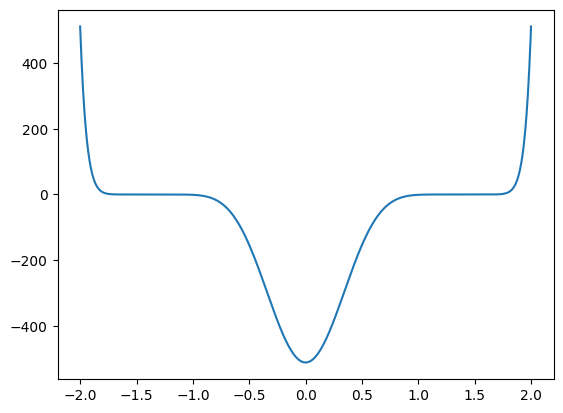

In [21]:
x = np.linspace(-2, 2, 1000)

plt.plot(x, f(x))
plt.show()

Utiliza la función **minimize** del submódulo **optimize** del módulo **scipy** con distintas inicializaciones para calcular los mínimos de la función definida anteriormente. 

In [22]:
from scipy.optimize import minimize

x0 = 3 # initial guess
res = minimize(f, x0, method='BFGS',
               options={'gtol':1e-6, 'disp':True})

print(f"Solución x = {res.x}")

x0 = 0.5 # initial guess
res2 = minimize(f, x0, method='BFGS',
               options={'gtol':1e-6, 'disp':True})

print(f"Solución 2 de x = {res2.x}")

x0 = -3 # initial guess
res2 = minimize(f, x0, method='BFGS',
               options={'gtol':1e-6, 'disp':True})

print(f"Solución 2 de x = {res2.x}")
# --------------------


Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 34
         Function evaluations: 78
         Gradient evaluations: 39
Solución x = [1.45294152]
Optimization terminated successfully.
         Current function value: -512.000000
         Iterations: 4
         Function evaluations: 14
         Gradient evaluations: 7
Solución 2 de x = [-1.02697578e-08]
Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 34
         Function evaluations: 78
         Gradient evaluations: 39
Solución 2 de x = [-1.45294154]


* Observamos que dependiendo del x0 tenemos un resultado, esto se debe a que tenemos puntos críticos donde la derivada es 0 en x = -1.45, x = 1.45 y en x = 0 y el algoritmo para cuando encuentra uno de ellos. Si nos fijamos en el mínimo, en este caso seria el x = 0, ya que el valor de la función es -512.

Consideremos ahora la función $$ f_1(x) = -\vert x - a \vert$$

Dibújala en un intervalo adecuado que te ayude a ayude a averiguar si se trata de 
una función coerciva. ¿Crees que se trata d euna función coerciva? ¿Por qué?

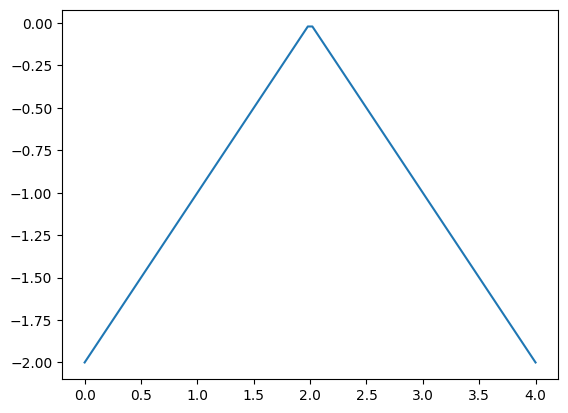

In [23]:
def f_2(x):
    return -abs(x-2)

x = np.linspace(0, 4, 100)

plt.plot(x, f_2(x))
plt.show()

* Esta función no es coerciva por que los limites al infinito no son +inf.

Añade un término de regularización de la forma $b\vert x\vert$ y dibuja la nueva función regularizada.

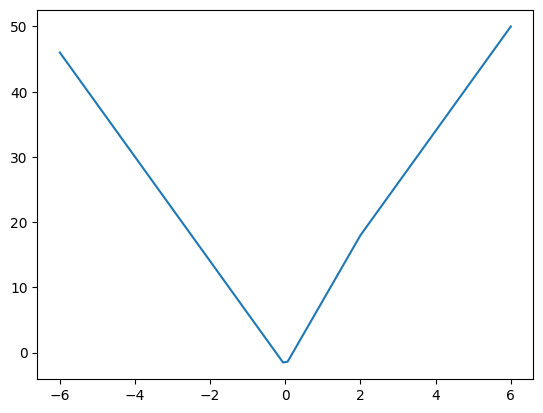

In [24]:
def f_reg(x):
    return -abs(x-2) + 9*abs(x)

x = np.linspace(-6, 6, 100)

plt.plot(x, f_reg(x))
plt.show()

Resuelve el problema de minimización siguiente usando el método **golden** de **minimize_scalar**:

$$
\text{Minimizar en } x\in\mathbb{R}: \quad f_{\text{reg}}(x) = f_1(x) + b\vert x\vert
$$

In [25]:
from scipy.optimize import minimize_scalar

res = minimize_scalar(f_reg, method='golden')
print(f'La solución es x = {res.x}')

La solución es x = 1.233581136681251e-17
